# Generative Models for Images

In [1]:
%pip install torch torchvision matplotlib numpy scikit-learn scipy


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Introduction

In the deep learning lecture, we built models that take an input $x$ and predict an output $y$: a classifier that maps an image to a label, or a regression model that maps features to a continuous value. These are **discriminative models** that learn the conditional distribution $p(y|x)$.

**Generative models** tackle a fundamentally different problem: learn the data distribution $p(x)$ itself, then sample from it to create new data. You have already encountered generative models in this course:

- **Gaussian mixture models** (EM algorithm lecture): model data as a mixture $p(x) = \sum_k \pi_k \mathcal{N}(x | \mu_k, \Sigma_k)$, with latent cluster assignments. The EM algorithm finds the parameters by iterating between inferring the latent variables (E-step) and maximizing the likelihood (M-step).
- **Bayesian models with MCMC** (MCMC lectures): specify a joint generative model $p(x, \theta) = p(x|\theta)p(\theta)$ and sample from the posterior. The generative model defines how data is produced given parameters.
- **Variational inference** (VI lecture): approximate the posterior $p(\theta|x)$ with a simpler distribution $q(\theta)$ by optimizing the ELBO. The VAE, which we will revisit in this lecture, extends this idea to learn both the generative model and the inference network simultaneously.
- **Large language models** (LLM lecture): model text as an autoregressive sequence $p(x_1, \ldots, x_n) = \prod_t p(x_t | x_{<t})$, generating one token at a time. LLMs are generative models for text, just as the models in this lecture are generative models for images.

All of these define a process for how data is generated. The models in this lecture scale these ideas to high-dimensional image data, where the "latent variables" are rich representations (noise vectors, latent codes, or noisy image trajectories) and the "generative process" is parameterized by deep neural networks.

In this lecture, we will cover four families of generative models for images:

* **Generative Adversarial Networks (GANs)**: a generator and discriminator play a minimax game
* **Variational Autoencoders (VAEs)**: encode data into a latent space and decode back, optimizing the ELBO
* **Flow-Based Models**: transform a simple distribution through invertible functions to get exact likelihoods
* **Diffusion Models**: gradually add noise to data, then learn to reverse the process

We will inspect lightweight implementations of all four on MNIST-scale examples, use precomputed results for the expensive training runs, compare the model families, and then explore the state of the art in 2026.

No code cell in this notebook trains a generative model from scratch. Whenever a result would require a multi-minute training run, we load a web-hosted or precomputed example instead.

![Overview of generative models (Lilian Weng)](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/generative-overview.png)

*Overview of generative model families. GANs, VAEs, flow-based models, and diffusion models each take a different approach to learning and sampling from $p(x)$. Figure from Lilian Weng's blog.*

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

FIG_DIR = Path("figs")


def show_figure(source, figsize=(8, 6), title=None):
    img = plt.imread(FIG_DIR / source)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis("off")
    if title is not None:
        ax.set_title(title, fontsize=14)
    plt.tight_layout()
    return fig, ax

Using device: cpu


### Loading MNIST

We will use MNIST throughout this lecture as a common benchmark for all three generative models. The images are 28x28 grayscale digits.

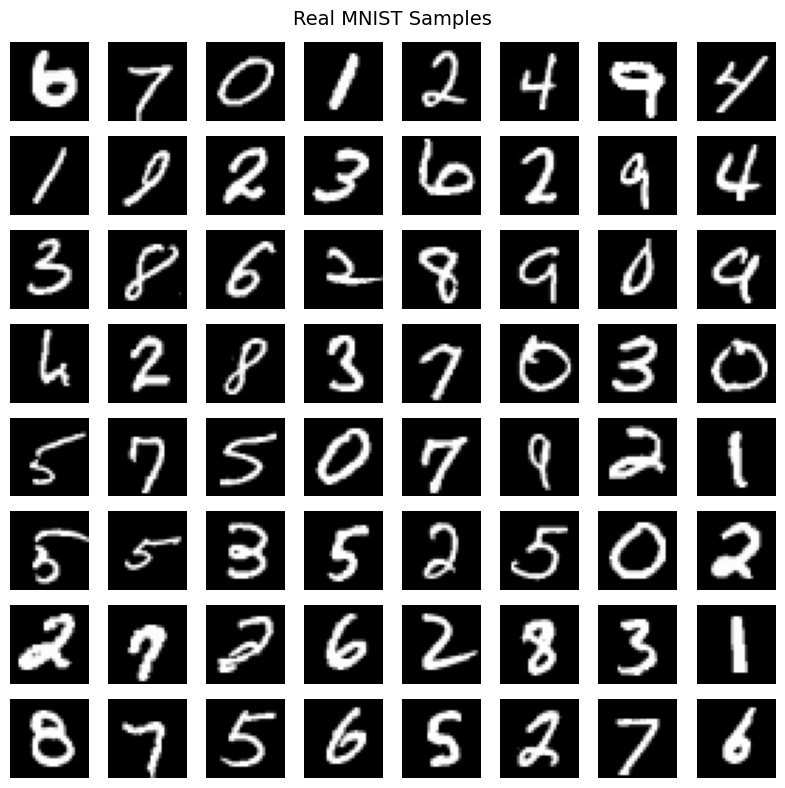

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # scale to [-1, 1]
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, drop_last=True)

# Show some real samples
real_batch = next(iter(train_loader))[0][:64]
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(real_batch[i, 0].cpu() * 0.5 + 0.5, cmap="gray")
    ax.axis("off")
fig.suptitle("Real MNIST Samples", fontsize=14)
plt.tight_layout()

## Generative Adversarial Networks (GANs)

GANs, introduced by Goodfellow et al. (2014), frame generative modeling as a two-player game between a **generator** $G$ and a **discriminator** $D$.

- The **generator** takes random noise $z \sim \mathcal{N}(0, I)$ and maps it to a fake image $G(z)$.
- The **discriminator** takes an image (real or fake) and outputs the probability that it is real.

The generator tries to fool the discriminator; the discriminator tries to distinguish real from fake. They are trained simultaneously via the minimax objective:

$$\min_G \max_D \; \mathbb{E}_{x \sim p_\text{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

When training converges, the generator produces images that the discriminator cannot distinguish from real data.

![xkcd 2650: Deepfakes](https://imgs.xkcd.com/comics/deepfakes.png)

*Generative models raise questions about what is "real." GANs were the first to produce photorealistic fake images at scale.*

### GAN Architecture

For MNIST, we use simple fully-connected networks. The generator maps a 64-dimensional noise vector to a 784-dimensional image (28x28). The discriminator maps a 784-dimensional image to a scalar probability.

In [4]:
class Generator(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 784),
            nn.Tanh()  # output in [-1, 1] to match data normalization
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x.view(-1, 784))

### Training a GAN

The training loop alternates between updating the discriminator (to better detect fakes) and updating the generator (to better fool the discriminator). In practice, even a small GAN training run can be unstable and can easily take longer than we want for an in-class demo, so here we only inspect the setup and then load precomputed results.

  latent_dim: 64
   optimizer: Adam(lr=2e-4, betas=(0.5, 0.999))
   objective: alternate discriminator and generator updates
  class_demo: load pretrained results saved locally instead of training live


(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'Pretrained GAN Samples on MNIST'}>)

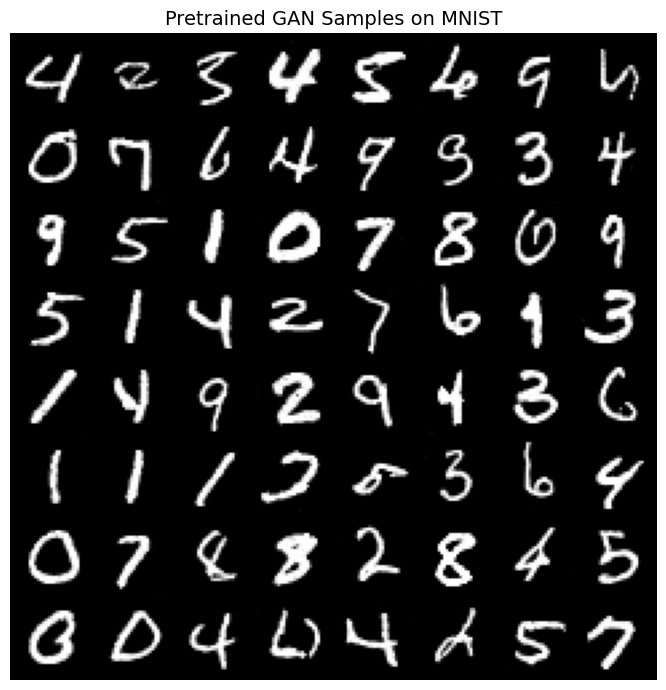

In [5]:
gan_demo_config = {
    "latent_dim": 64,
    "optimizer": "Adam(lr=2e-4, betas=(0.5, 0.999))",
    "objective": "alternate discriminator and generator updates",
    "class_demo": "load pretrained results saved locally instead of training live",
}

for key, value in gan_demo_config.items():
    print(f"{key:>12}: {value}")

show_figure(
    "generative-models-gan-pretrained-web.png",
    figsize=(7, 7),
    title="Pretrained GAN Samples on MNIST",
)

After training, we sample by passing random noise through the generator: `gen(torch.randn(64, latent_dim))`. The panel above shows a pretrained MNIST DCGAN sample grid that we saved locally for the lecture rather than anything produced by this notebook.

### GAN Training Instabilities

GANs are notoriously difficult to train. The minimax game can fail to converge for several reasons:

**Mode collapse.** The generator learns to produce only a small subset of the data distribution. Instead of generating all 10 digits, it might produce only 1s and 7s because those are enough to fool the discriminator.

**Vanishing gradients.** If the discriminator becomes too good, it outputs near-zero probabilities for all fake images. The gradient $\nabla_G \log(1 - D(G(z)))$ vanishes, and the generator stops learning.

**Oscillation.** The generator and discriminator can chase each other in circles without converging.

(<Figure size 1000x250 with 1 Axes>,
 <Axes: title={'center': 'GAN Outputs After 100 Epochs: Much Better Digits'}>)

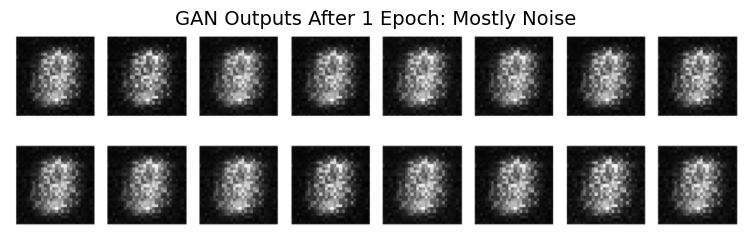

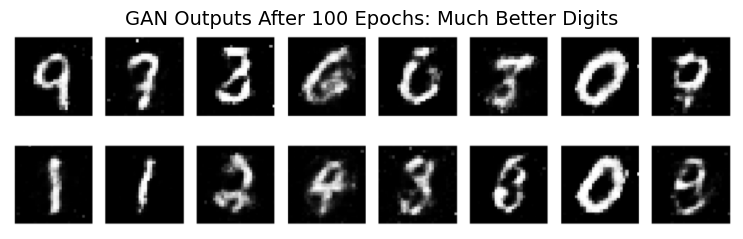

In [6]:
show_figure(
    "generative-models-gan-epoch1-web.png",
    figsize=(10, 2.5),
    title="GAN Outputs After 1 Epoch: Mostly Noise",
)

show_figure(
    "generative-models-gan-epoch100-web.png",
    figsize=(10, 2.5),
    title="GAN Outputs After 100 Epochs: Much Better Digits",
)

These saved snapshots also show why we avoid live GAN training in lecture: sample quality changes a lot over training, and the run is both slow and unstable.

### GAN Variants

Several variants address these instabilities:

- **DCGAN** (2015): Uses convolutional layers and batch normalization. Established architectural guidelines (no fully-connected layers in the generator, use strided convolutions instead of pooling).
- **WGAN** (2017): Replaces the binary cross-entropy loss with the Wasserstein distance. Provides smoother gradients and a meaningful loss metric that correlates with sample quality.
- **StyleGAN** (2019): Produces photorealistic faces at 1024x1024 by using a style-based generator with adaptive instance normalization.

![StyleGAN generated faces (NVIDIA)](https://raw.githubusercontent.com/NVlabs/stylegan/master/stylegan-teaser.png)

*Faces generated by StyleGAN (Karras et al., 2019). None of these people exist. The model learned the distribution of human faces and can sample from it. The rows show style mixing at different resolutions.*

### Question 1

The GAN objective is $\min_G \max_D \; \mathbb{E}[\log D(x)] + \mathbb{E}[\log(1 - D(G(z)))]$.

1. At the Nash equilibrium, what is the optimal discriminator $D^*(x)$ for a fixed generator?
2. Why might the generator collapse to producing only a few types of images (mode collapse)? How does this relate to the Nash equilibrium?
3. If we train the discriminator to convergence before each generator update (instead of alternating single steps), would this help or hurt?

### Answer

1. For a fixed generator, the optimal discriminator is $D^*(x) = \frac{p_\text{data}(x)}{p_\text{data}(x) + p_g(x)}$. At the Nash equilibrium where $p_g = p_\text{data}$, we get $D^*(x) = 1/2$ for all $x$: the discriminator can do no better than random guessing.

2. Mode collapse happens because the generator can minimize its loss by finding a single mode that reliably fools the discriminator. The discriminator then adapts to reject that mode, the generator switches to another, and so on. The minimax game has a saddle point (Nash equilibrium) where $p_g = p_\text{data}$, but gradient descent does not guarantee convergence to saddle points. Instead, the dynamics can cycle around the equilibrium.

3. Training the discriminator to convergence would make the discriminator too strong, leading to vanishing gradients for the generator. The generator needs a "confused" discriminator to get useful gradient signal. In practice, alternating a small number of discriminator steps per generator step works best.

## Variational Autoencoders (VAEs)

VAEs, introduced by Kingma & Welling (2014), take a probabilistic approach to generation. You already know the key ideas from the variational inference lecture. Here we apply them specifically to image generation.

A VAE consists of:

- An **encoder** $q_\phi(z|x)$ that maps an image $x$ to a distribution over latent codes $z$
- A **decoder** $p_\theta(x|z)$ that maps a latent code $z$ back to an image

Training maximizes the **ELBO** (Evidence Lower Bound):

$$\mathcal{L}(\theta, \phi; x) = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - D_\text{KL}(q_\phi(z|x) \| p(z))$$

The first term is the reconstruction loss (how well can we recover $x$ from $z$). The second term regularizes the latent space to be close to the prior $p(z) = \mathcal{N}(0, I)$. You derived this in the variational inference lecture as a special case of the general ELBO.

The **reparameterization trick** (also from the VI lecture) enables backpropagation through the stochastic sampling: $z = \mu + \sigma \odot \epsilon$ where $\epsilon \sim \mathcal{N}(0, I)$.

### VAE Architecture

In [7]:
class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.enc = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Decoder
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def encode(self, x):
        h = self.enc(x.view(-1, 784))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        return self.dec(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


def vae_loss(recon, x, mu, logvar):
    recon_loss = F.mse_loss(recon, x, reduction="sum")
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

### Training a VAE

The training loop is straightforward: for each batch, encode, reparameterize, decode, compute ELBO loss, backpropagate. This is lighter than a GAN or diffusion model, but we still avoid running a full multi-epoch training job live and instead inspect precomputed outputs.

  latent_dim: 16
   optimizer: Adam(lr=1e-3)
   objective: reconstruction loss + KL penalty
  class_demo: load precomputed reconstructions instead of training live


(<Figure size 1000x300 with 1 Axes>,
 <Axes: title={'center': 'Precomputed VAE Reconstructions'}>)

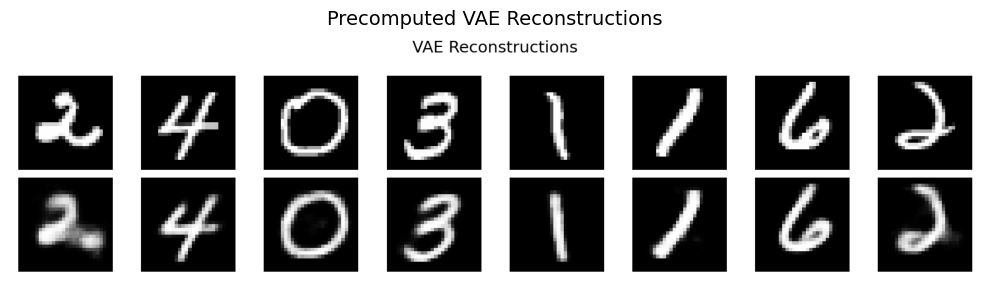

In [8]:
vae_demo_config = {
    "latent_dim": 16,
    "optimizer": "Adam(lr=1e-3)",
    "objective": "reconstruction loss + KL penalty",
    "class_demo": "load precomputed reconstructions instead of training live",
}

for key, value in vae_demo_config.items():
    print(f"{key:>12}: {value}")

show_figure(
    "generative-models-vae-recon.png",
    figsize=(10, 3),
    title="Precomputed VAE Reconstructions",
)

After training, we can reconstruct inputs (encode then decode) and generate new samples (sample $z \sim \mathcal{N}(0, I)$ then decode):

(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'Precomputed VAE Samples on MNIST'}>)

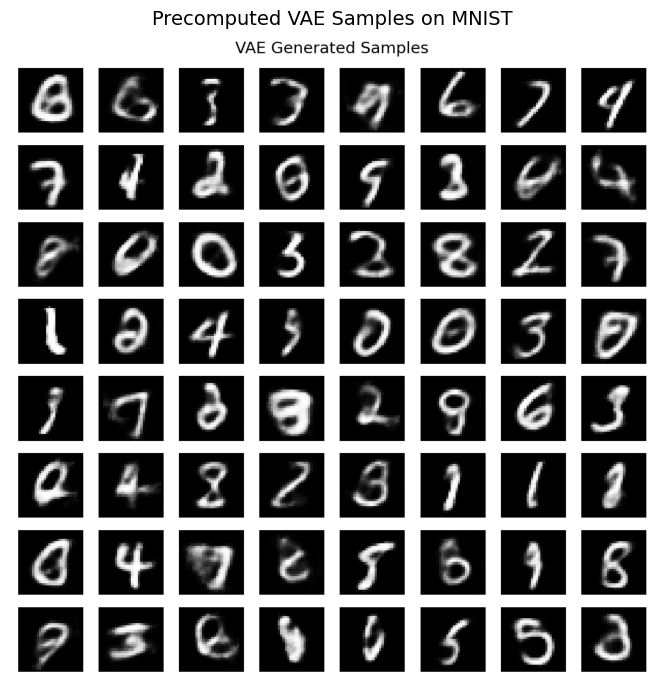

In [9]:
show_figure(
    "generative-models-vae-samples.png",
    figsize=(7, 7),
    title="Precomputed VAE Samples on MNIST",
)

Notice that the samples are recognizable but slightly blurry compared to GAN outputs. This blurriness is a characteristic limitation of VAEs.

### Latent Space Interpolation

One advantage of VAEs over GANs is a smooth, structured latent space. We can interpolate between two images by interpolating their latent codes: $z_\alpha = (1-\alpha) z_a + \alpha z_b$.

(<Figure size 1200x220 with 1 Axes>,
 <Axes: title={'center': 'Precomputed VAE Latent Interpolation'}>)

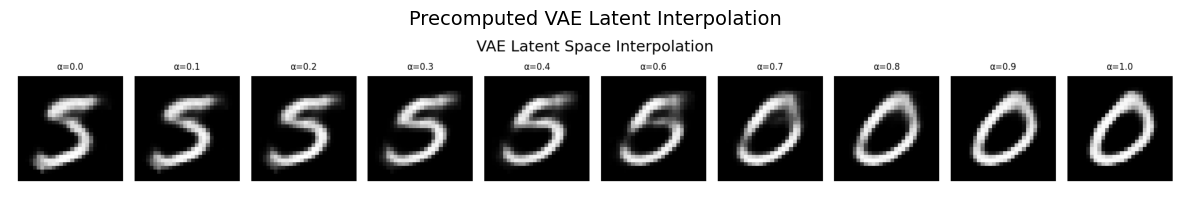

In [10]:
show_figure(
    "generative-models-vae-interpolation.png",
    figsize=(12, 2.2),
    title="Precomputed VAE Latent Interpolation",
)

The smooth transition shows that the latent space is well-structured: nearby latent codes decode to similar images.

With a 2D latent space, we can visualize the entire latent manifold by decoding a grid of $z$ values:

![VAE latent space manifold](https://raw.githubusercontent.com/chaitanya100100/VAE-for-Image-Generation/master/images/ld_2_e_60_uniform.png)

*MNIST digit manifold: each point in this grid corresponds to a $z$ value decoded by the VAE. The smooth transitions between digit classes show the VAE has learned a meaningful latent representation.*

### VAE Strengths and Weaknesses

**Strengths:**

- Stable training (no adversarial dynamics)
- Meaningful latent space with smooth interpolation
- Tractable likelihood bound (the ELBO)
- Principled probabilistic framework

**Weakness: blurry samples.** VAE-generated images tend to be blurry compared to GAN outputs. This stems from the reconstruction loss: MSE penalizes pixel-wise deviations, which causes the decoder to output the average of plausible reconstructions rather than committing to any single sharp reconstruction.

### Question 2

The VAE's reconstruction loss is $\mathbb{E}_{q(z|x)}[\|x - \hat{x}\|^2]$, which is MSE between the input and reconstruction.

1. VAE samples are often blurrier than GAN samples. Why does minimizing MSE lead to blurry images? (Hint: consider a pixel that could be black or white with equal probability.)
2. The KL term $D_\text{KL}(q_\phi(z|x) \| p(z))$ pulls the encoder toward the prior $\mathcal{N}(0,I)$. What happens if we remove it (set its weight to 0)? What happens if we make it very large?
3. In the variational inference lecture, we discussed the difference between $D_\text{KL}(q \| p)$ and $D_\text{KL}(p \| q)$. Which direction does the VAE use, and how does this affect the learned latent space?

### Answer

1. If a pixel could be 0 or 1 with equal probability, the MSE-optimal prediction is 0.5 (the mean), which is blurry. MSE penalizes large deviations quadratically, so the network hedges by predicting the expected value rather than committing to either possibility. GANs avoid this because the discriminator can detect blurriness. Diffusion models avoid this because they denoise iteratively, making small corrections at each step.

2. Without the KL term (weight=0), the model becomes a standard autoencoder. The latent space is no longer regularized and can be arbitrarily structured, so sampling $z \sim \mathcal{N}(0,I)$ produces garbage. With very large KL weight, the encoder is forced to output exactly $\mathcal{N}(0,I)$ for all inputs, meaning $z$ carries no information about $x$. All reconstructions would look like the dataset average. The weight balances information content in $z$ against regularity of the latent space.

3. The VAE ELBO uses $D_\text{KL}(q_\phi(z|x) \| p(z))$, which penalizes the encoder for placing probability mass where the prior $p(z)$ is low. This encourages the encoder to spread its outputs across the prior's support rather than concentrating in a small region. As a result, different inputs tend to map to overlapping regions of latent space, creating a smooth, connected manifold. This is why interpolation between latent codes produces smooth transitions. If the KL were reversed ($D_\text{KL}(p(z) \| q_\phi(z|x))$), the encoder could concentrate in narrow regions while ignoring much of the prior's support, creating a fragmented latent space with gaps.

## Flow-Based Models

Flow-based models take a fundamentally different approach from GANs and VAEs: they learn an **invertible transformation** $f$ that maps a simple distribution (e.g., $\mathcal{N}(0, I)$) to the data distribution. Because the transformation is invertible, we can compute exact likelihoods using the **change of variables formula**.

### The Change of Variables Formula

If $z \sim p_z(z)$ and $x = f(z)$ where $f$ is invertible and differentiable, then:

$$p_x(x) = p_z(f^{-1}(x)) \left|\det \frac{\partial f^{-1}}{\partial x}\right|$$

Taking the log:

$$\log p_x(x) = \log p_z(f^{-1}(x)) + \log \left|\det \frac{\partial f^{-1}}{\partial x}\right|$$

This gives us the **exact log-likelihood** of any data point, not just a lower bound (like the VAE's ELBO). Training maximizes this log-likelihood directly via gradient descent.

The challenge is designing transformations that are:

1. **Expressive** enough to map a Gaussian to complex data distributions
2. **Invertible** so we can compute $f^{-1}(x)$ for likelihood evaluation
3. **Efficient** to compute the Jacobian determinant (a naive $d \times d$ determinant is $O(d^3)$)

### Normalizing Flows

A **normalizing flow** constructs the transformation $f$ as a composition of simple invertible layers:

$$x = f_K \circ f_{K-1} \circ \cdots \circ f_1(z)$$

The log-determinant of the full Jacobian decomposes into a sum:

$$\log \left|\det \frac{\partial f^{-1}}{\partial x}\right| = \sum_{k=1}^{K} \log \left|\det \frac{\partial f_k^{-1}}{\partial h_k}\right|$$

Each layer $f_k$ is designed so that its Jacobian determinant is cheap to compute.

**Affine coupling layers** (Dinh et al., 2017, RealNVP) are the most common building block. The input is split into two halves $(x_a, x_b)$, and the transformation is:

$$y_a = x_a \quad \text{(identity)}$$
$$y_b = x_b \odot \exp(s(x_a)) + t(x_a) \quad \text{(affine transform)}$$

where $s$ and $t$ are arbitrary neural networks. This is invertible (solve for $x_b$ given $y_b$ and $x_a$), and the Jacobian is triangular, so the determinant is just $\exp(\sum s(x_a))$, which is $O(d)$ instead of $O(d^3)$.

### Implementation: Normalizing Flow on 2D Data

To illustrate the concept, we build a small normalizing flow that transforms a 2D Gaussian into a more complex distribution. We will instantiate the model locally, verify the forward/inverse map, and use a precomputed training result for the final density plot.

In [11]:
class AffineCouplingLayer(nn.Module):
    """Affine coupling layer: transforms one half conditioned on the other."""
    def __init__(self, dim, hidden_dim=64):
        super().__init__()
        half_dim = dim // 2
        self.net = nn.Sequential(
            nn.Linear(half_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, half_dim * 2)  # outputs s and t
        )
        self.half_dim = half_dim

    def forward(self, x):
        """Forward: z -> x direction (generation)."""
        x_a, x_b = x[..., :self.half_dim], x[..., self.half_dim:]
        st = self.net(x_a)
        s, t = st[..., :self.half_dim], st[..., self.half_dim:]
        y_a = x_a
        y_b = x_b * torch.exp(s) + t
        log_det = s.sum(dim=-1)
        return torch.cat([y_a, y_b], dim=-1), log_det

    def inverse(self, y):
        """Inverse: x -> z direction (likelihood evaluation)."""
        y_a, y_b = y[..., :self.half_dim], y[..., self.half_dim:]
        st = self.net(y_a)
        s, t = st[..., :self.half_dim], st[..., self.half_dim:]
        x_a = y_a
        x_b = (y_b - t) * torch.exp(-s)
        log_det = -s.sum(dim=-1)
        return torch.cat([x_a, x_b], dim=-1), log_det


class NormalizingFlow(nn.Module):
    """Stack of affine coupling layers with alternating splits."""
    def __init__(self, dim=2, n_layers=6, hidden_dim=64):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            self.layers.append(AffineCouplingLayer(dim, hidden_dim))
            # Permute dimensions between layers so both halves get transformed
        self.dim = dim

    def forward(self, z):
        """z -> x (generation)."""
        log_det_total = 0
        x = z
        for i, layer in enumerate(self.layers):
            x, log_det = layer(x)
            log_det_total += log_det
            x = torch.flip(x, dims=[-1])  # swap halves
        return x, log_det_total

    def inverse(self, x):
        """x -> z (for likelihood computation)."""
        log_det_total = 0
        z = x
        for i, layer in reversed(list(enumerate(self.layers))):
            z = torch.flip(z, dims=[-1])  # undo swap
            z, log_det = layer.inverse(z)
            log_det_total += log_det
        return z, log_det_total

    def log_prob(self, x):
        """Compute exact log-likelihood of x."""
        z, log_det = self.inverse(x)
        log_pz = -0.5 * (z ** 2 + np.log(2 * np.pi)).sum(dim=-1)
        return log_pz + log_det

In [12]:
flow = NormalizingFlow(dim=2, n_layers=6, hidden_dim=64).to(device)
z_demo = torch.randn(5, 2, device=device)
x_demo, log_det_demo = flow(z_demo)
z_recovered, inv_log_det_demo = flow.inverse(x_demo)

print("Max reconstruction error:", (z_demo - z_recovered).abs().max().item())
print("Forward/inverse log-det agreement:", (log_det_demo + inv_log_det_demo).abs().max().item())

Max reconstruction error: 1.1920928955078125e-07
Forward/inverse log-det agreement: 5.960464477539063e-08


(<Figure size 1500x400 with 1 Axes>,
 <Axes: title={'center': 'Precomputed 2D Normalizing Flow Demo'}>)

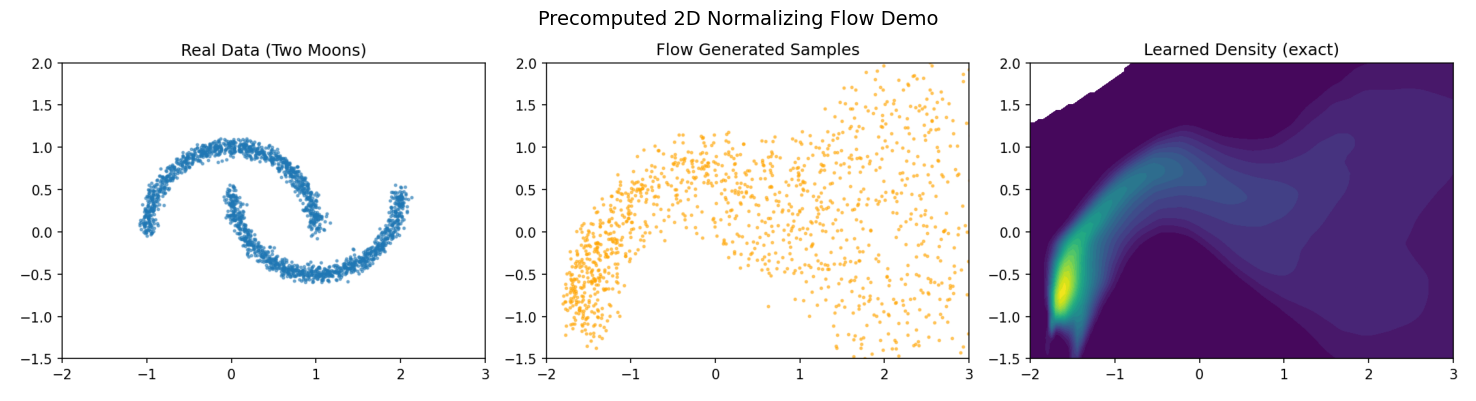

In [13]:
show_figure(
    "generative-models-flow-2d.png",
    figsize=(15, 4),
    title="Precomputed 2D Normalizing Flow Demo",
)

The key advantage is visible in the right panel: the flow provides an **exact density** at every point, not just samples.

### Flow-Based Models for Images

For images, flows use convolutional coupling layers and multi-scale architectures:

- **RealNVP** (Dinh et al., 2017): Affine coupling layers with checkerboard and channel-wise splits. Produces reasonable but somewhat blurry images.
- **Glow** (Kingma & Dhariwal, 2018): Adds invertible 1x1 convolutions and actnorm. Produces sharp faces at 256x256 with exact likelihood.

**Strengths:**

- Exact log-likelihood (no lower bounds, no adversarial training)
- Invertible: can compute both $p(x)$ and generate $x$ from $z$
- Meaningful latent space with smooth interpolation (like VAEs, but without the blurriness)

**Weaknesses:**

- Invertibility constraint limits architecture flexibility (cannot use pooling, dropout, or arbitrary layers)
- Memory-intensive: must store activations for all layers (though reversible architectures can help)
- Image quality historically lagged behind GANs and diffusion models, though modern flow matching has closed the gap

#### Glow: High-Resolution Face Generation

Glow (Kingma & Dhariwal, 2018) demonstrated that flow-based models can generate sharp, high-resolution images with exact likelihood computation. Below are synthetic celebrity faces sampled from a Glow model trained on CelebA-HQ at 256x256.

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Glow: Synthetic Celebrity Faces (Kingma & Dhariwal, 2018)'}>)

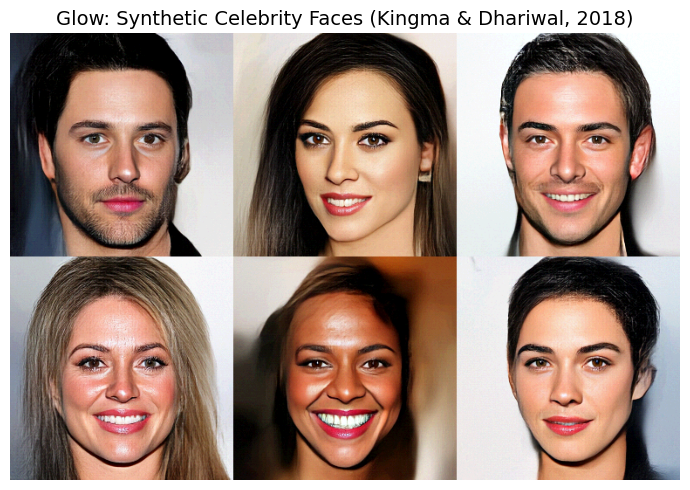

In [14]:
show_figure(
    "generative-models-glow-samples.png",
    figsize=(8, 5),
    title="Glow: Synthetic Celebrity Faces (Kingma & Dhariwal, 2018)",
)

Because the latent space is obtained through an invertible map, interpolating between two latent codes produces smooth, semantically meaningful transitions between faces:

(<Figure size 1400x500 with 1 Axes>,
 <Axes: title={'center': 'Glow: Latent Space Interpolation Between Real Faces'}>)

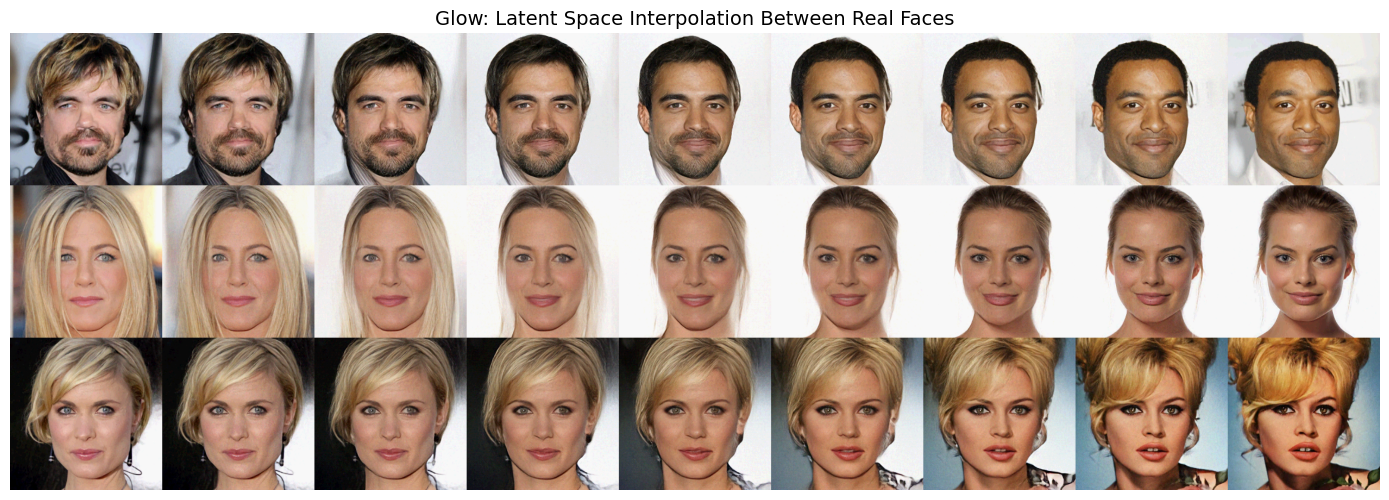

In [15]:
show_figure(
    "generative-models-glow-interpolation.png",
    figsize=(14, 5),
    title="Glow: Latent Space Interpolation Between Real Faces",
)

#### Beyond Normalizing Flows: Flow Matching

Flow matching (Lipman et al., 2023) is a newer approach inspired by the flow idea but formulated differently. Instead of learning invertible coupling layers with exact likelihoods, it learns a continuous-time velocity field that transports noise to data along straight paths. This relaxes the invertibility constraint and allows more flexible architectures, though it no longer provides exact likelihoods. Stable Diffusion 3 (Esser et al., 2024) uses rectified flow matching at scale:

(<Figure size 1200x700 with 1 Axes>,
 <Axes: title={'center': 'Stable Diffusion 3: Rectified Flow Matching Samples (Esser et al., 2024)'}>)

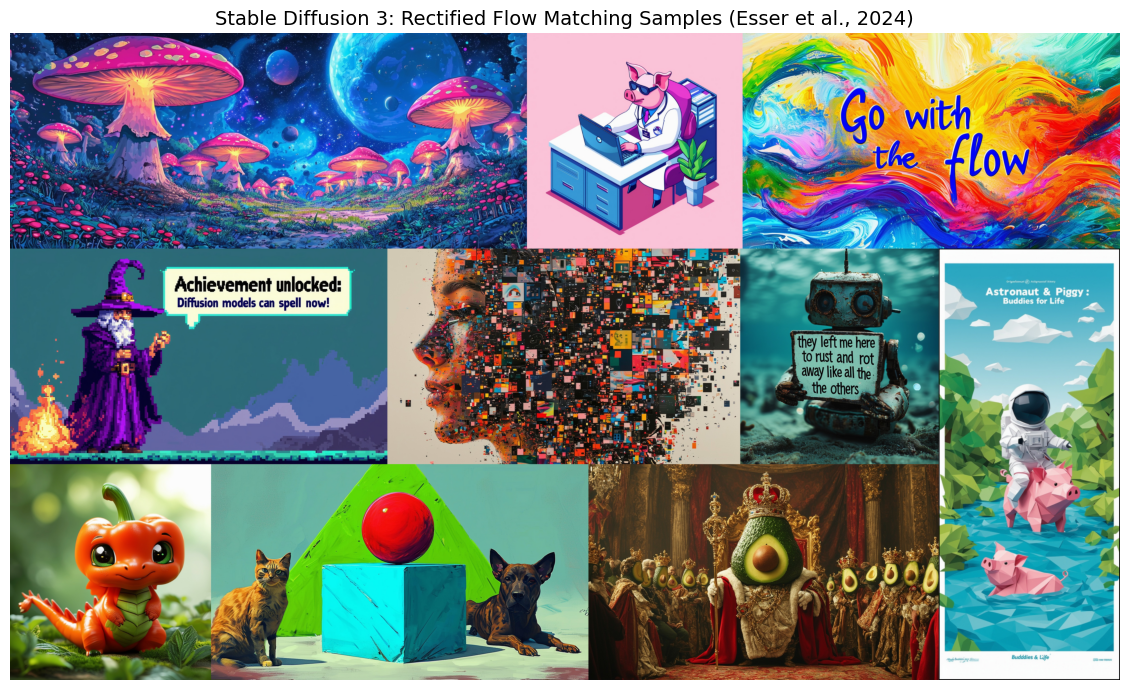

In [16]:
show_figure(
    "generative-models-sd3-flow-matching.jpg",
    figsize=(12, 7),
    title="Stable Diffusion 3: Rectified Flow Matching Samples (Esser et al., 2024)",
)

These examples show the progression from early coupling-layer architectures (RealNVP, Glow) to modern flow matching, which has closed the historical quality gap between flow-based methods and other generative model families.

### Question 3

The change of variables formula gives $\log p(x) = \log p_z(f^{-1}(x)) + \log|\det J_{f^{-1}}|$.

1. The VAE optimizes a lower bound (ELBO) on $\log p(x)$. The flow optimizes $\log p(x)$ exactly. Why might you still prefer a VAE over a flow?
2. Affine coupling layers leave half the dimensions unchanged ($y_a = x_a$). How does the flow still manage to transform all dimensions of the data?
3. Computing the determinant of a general $d \times d$ matrix is $O(d^3)$. For a 28x28 grayscale image, $d = 784$. How do coupling layers avoid this cost?

### Answer

1. Despite the exact likelihood, flows are constrained to invertible architectures, which limits expressiveness. VAEs can use any encoder/decoder architecture (pooling, dropout, arbitrary depth). In practice, VAE latent spaces are often more useful for downstream tasks (classification, clustering) because the KL regularization encourages disentangled representations. Flows also require more memory since all activations must be stored for invertibility. The choice depends on whether you need exact likelihoods or flexible representations.

2. By alternating which half is kept fixed across layers. In layer $k$, the first half is fixed and the second half is transformed conditioned on the first. In layer $k+1$, the split is swapped (or a permutation is applied), so the previously fixed dimensions are now transformed. After several layers, every dimension has been transformed multiple times, conditioned on all other dimensions.

3. The Jacobian of a coupling layer is **triangular** (because $y_a = x_a$ contributes an identity block, and $\partial y_b / \partial x_a$ goes below the diagonal). The determinant of a triangular matrix is just the product of its diagonal entries, which is $O(d)$. For our 784-dimensional image, this is $784$ multiplications instead of a $784 \times 784$ determinant.

## Diffusion Models

Diffusion models are the newest and most powerful of the four families. They were introduced by Sohl-Dickstein et al. (2015) and made practical by Ho et al. (2020) with **Denoising Diffusion Probabilistic Models (DDPM)**. Diffusion models now power state-of-the-art image generation systems including Stable Diffusion, DALL-E, and Midjourney.

The core idea is beautifully simple:

1. **Forward process**: Gradually add Gaussian noise to an image until it becomes pure noise
2. **Reverse process**: Train a neural network to undo each noise step, recovering the image

This connects to ideas you already know: the forward process is a **Markov chain** (from the MCMC lecture) that converges to a known stationary distribution $\mathcal{N}(0, I)$. The training objective is derived from the **ELBO** (from the variational inference lecture). The neural network uses architectures from the **deep learning** lecture.

![Forward and reverse diffusion process (Lilian Weng)](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/DDPM.png)

*The forward process gradually adds noise over $T$ steps (left to right). The reverse process learns to denoise step by step (right to left). Figure from Lilian Weng's blog.*

We will walk through how diffusion works using Stable Diffusion as a concrete example, building intuition for each component before connecting them together. While the illustrations focus on Stable Diffusion's latent diffusion architecture, the core principles (adding noise, training a noise predictor, iterative denoising) apply to all diffusion models.

### The Components of a Diffusion System

A modern diffusion-based image generator like Stable Diffusion is not one monolithic model. It is a system made up of several components, each handling a different part of the generation process.

At a high level, the system has a **text understanding** component and an **image generation** component:

![Text understanding and image generation](figs/sd-stable-diffusion-text-understanding-component-image-generation.png)

The text encoder is a special Transformer language model. Specifically, it is the text encoder of a CLIP model. It takes the input text and converts it into a list of numeric vectors (token embeddings) that represent each word or token in the text.

![Text info to image generator](figs/sd-Stable-diffusion-text-info-to-image-generator.png)

### The Image Generator

The image generation component itself has two stages:

**Stage 1: Image Information Creator.** This is the core of the diffusion process. It runs for multiple steps (the "denoising" steps, typically 50-100 during inference), and each step refines an array of numbers called a **latent** that represents the image being generated. The image information creator is composed of a U-Net neural network and a **scheduler** (also called a sampler). The U-Net predicts the noise in the current latent, and the scheduler decides *how* to use that prediction to update the latent for the next step. Different schedulers implement different update rules: for example, DDPM adds a stochastic term at each step, while DDIM uses a deterministic update that allows skipping steps. The scheduler also controls the **noise schedule** ($\beta_t$), which determines how much noise is added at each timestep during training and how aggressively the latent is denoised during generation.

![Image information creator](figs/sd-Stable-diffusion-image-generator-information-creator.png)

**Stage 2: Image Decoder.** After the information creator finishes its work, the resulting array of numbers is passed to the decoder, which paints the final pixel image.

![ClipText, UNet, and Autoencoder Decoder](figs/sd-stable-diffusion-cliptext-unet-autoencoder-decoder.png)

Putting it all together, the three main components and their input/output tensors look like this:

![Components and tensors](figs/sd-stable-diffusion-components-and-tensors.png)

1. **ClipText** for text encoding. Input: text. Output: 77 token embedding vectors, each 768 dimensions.
2. **UNet + Scheduler** for gradual processing of information in latent space. Input: text embeddings and a starting noise tensor. Output: a processed information array.
3. **Autoencoder Decoder** for painting the final image. Input: the processed information array (dimensions 4 x 64 x 64). Output: the resulting image (dimensions 3 x 512 x 512, i.e. RGB at 512x512).

### What Is Diffusion?

The process that happens inside the image information creator works entirely in "latent space," a compressed representation of images. The decoder then converts these latents into the pixel images we see.

To build intuition, consider what happens when we take a random latent (just random numbers) and pass it directly through the decoder:

![Latent space to pixel space](figs/sd-stable-diffusion-latent-space-pixel-space.png)

The result is visual noise. The diffusion process starts from this random noise and gradually refines it, step by step, into a coherent image.

![UNet steps](figs/sd-stable-diffusion-unet-steps.png)

At each step, the U-Net takes the current noisy latent and produces updated latent arrays that look increasingly like the image described by the input text:

![Denoising steps latents](figs/sd-stable-diffusion-denoising-steps-latents.png)

Visualizing these intermediate latents through the decoder shows the gradual emergence of structure: outlines appear first, then shapes, then textures and details.

### How Diffusion Training Works

Diffusion training is built on a simple idea: take images, add noise, and train a neural network to predict what noise was added. This is the **forward diffusion** process.

Given a training image, we generate random noise and add it to the image:

![Forward diffusion training example](figs/sd-stable-diffusion-forward-diffusion-training-example.png)

The amount of noise can vary. The noise scheduling algorithm can add small or large amounts of noise, producing images at different corruption levels:

![Forward diffusion training example 2](figs/sd-stable-diffusion-forward-diffusion-training-example-2.png)

By applying this to many images from the training dataset with varying noise levels, we obtain a large collection of training examples:

![UNet noise training examples](figs/sd-stable-diffusion-u-net-noise-training-examples-2.png)

Each training step feeds a noisy image (along with the noise level) into the U-Net, which predicts the noise. The loss is the difference between the predicted noise and the actual noise that was added:

![UNet noise training step](figs/sd-stable-diffusion-u-net-noise-training-step.png)

Mathematically, the training objective is:

$$L_\text{simple} = \mathbb{E}_{t, x_0, \epsilon}\left[\|\epsilon - \epsilon_\theta(x_t, t)\|^2\right]$$

where $x_0$ is a training image, $t$ is a random timestep, $\epsilon$ is the noise added, and $\epsilon_\theta$ is the U-Net's prediction. This simple mean-squared-error loss turns out to be a simplified form of the variational lower bound (ELBO) from the variational inference framework.

The full training loop, summarized as a flowchart:

```mermaid
flowchart TD
    A["Sample x₀ from dataset"] --> B["Sample t ~ Uniform{1,...,T}"]
    B --> C["Sample ε ~ N(0, I)"]
    C --> D["Compute x_t = √ᾱ_t · x₀ + √(1-ᾱ_t) · ε"]
    D --> E["Predict ε̂ = ε_θ(x_t, t)"]
    E --> F["Loss = ‖ε - ε̂‖²"]
    F --> G["Backpropagation + optimizer step"]
    G --> A
```

### Generating Images by Removing Noise

Once trained, the noise predictor can generate images by starting from pure random noise and iteratively removing predicted noise:

![Denoising step 1](figs/sd-stable-diffusion-denoising-step-1v2.png)

The noise predictor takes the noisy image and the denoising step number as input, and outputs a noise prediction. A scheduling algorithm then uses this prediction to compute a less noisy version of the image (the exact update rule depends on the sampler and involves scaling coefficients, not simple subtraction):

![Denoising step 2](figs/sd-stable-diffusion-denoising-step-2v2.png)

Repeating this process over many steps gradually transforms random noise into a coherent image:

![Image generation](figs/sd-stable-diffusion-image-generation-v2.png)

If the training dataset consisted of aesthetically pleasing images (Stable Diffusion was trained on LAION Aesthetics), the resulting images tend to be aesthetically pleasing as well. This describes the core principles found in Denoising Diffusion Probabilistic Models (Ho et al., 2020).

### Speed Boost: Diffusion on Compressed Data

Running diffusion directly on full-resolution images (e.g. 512 x 512 x 3) is computationally very expensive because the U-Net must process high-dimensional tensors at every step. The key insight of **Latent Diffusion Models** (Rombach et al., 2022) is to first compress images into a smaller latent representation using a pretrained autoencoder, then run the diffusion process in that compressed space.

The autoencoder is trained separately to compress images and faithfully reconstruct them:

![Autoencoder](figs/sd-stable-diffusion-autoencoder.png)

Now the forward diffusion process (adding noise) and the reverse process (denoising) both operate on these compact latents instead of full-resolution images:

![Latent forward process](figs/sd-stable-diffusion-latent-forward-process-v2.png)

The full pipeline for both training (forward process) and generation (reverse process) looks like this:

![Forward and reverse process](figs/sd-stable-diffusion-forward-and-reverse-process-v2.png)

By compressing a 512 x 512 x 3 image down to a 64 x 64 x 4 latent (a 48x reduction in the number of values), the U-Net processes much smaller tensors at each step, dramatically speeding up both training and inference.

The original Latent Diffusion paper (Figure 3) shows how text conditioning is added on top of this latent diffusion framework:

![Latent Diffusion Figure 3](figs/sd-article-Figure3-1-1536x762.png)

### The Text Encoder: CLIP

For text-to-image generation, the system needs to understand text prompts. Stable Diffusion uses a CLIP text encoder for this purpose.

The choice of language model matters a lot. Larger and better language models significantly improve the quality of generated images:

![Language models and image generation](figs/sd-text-language-models-clip-image-generation.png)

*Larger language models have a significant effect on the quality of image generation models (Saharia et al., Google Imagen).*

Early Stable Diffusion models used a pretrained CLIP text encoder. Later versions (v2 and beyond) moved to larger OpenCLIP variants for improved text understanding.

**How CLIP is trained.** CLIP learns to connect images and text by training on a dataset of image-caption pairs:

![Images and captions dataset](figs/sd-images-and-captions-dataset.png)

The training process works as follows. Both images and text are encoded into embedding vectors:

![CLIP training step 1](figs/sd-clip-training-step-1.png)

The model compares these embeddings using cosine similarity:

![CLIP training step 2](figs/sd-clip-training-step-2.png)

The model is updated to maximize the similarity of matching image-text pairs while minimizing it for non-matching pairs:

![CLIP training step 3](figs/sd-clip-training-step-3.png)

After training, CLIP's text encoder produces embeddings that capture the semantic meaning of text in a way that is aligned with visual concepts.

### Feeding Text into Image Generation

The noise predictor (U-Net) must use text information to guide the denoising process. Here is the overall view of the U-Net's inputs when text conditioning is included:

![UNet inputs with text](figs/sd-stable-diffusion-unet-inputs-v2.png)

During training, the dataset now includes the encoded text alongside the noisy latents and noise targets:

![Text dataset](figs/sd-stable-diffusion-text-dataset-v2.png)

### The U-Net Noise Predictor

Without text conditioning, the U-Net processes the noisy latent through a series of layers:

![UNet inputs and outputs](figs/sd-unet-inputs-outputs-v2.png)

The architecture consists of ResNet blocks that transform the latent representation, with residual connections and timestep embeddings:

![ResNet steps](figs/sd-unit-resnet-steps-v2.png)

To incorporate text, the architecture is modified to add **attention layers** between the ResNet blocks:

![UNet with text inputs and outputs](figs/sd-unet-with-text-inputs-outputs-v2.png)

These attention layers allow the text embeddings to influence the image generation process. At each attention layer, the text token embeddings serve as keys and values while the image features serve as queries, allowing downstream ResNet blocks to incorporate the textual information:

![UNet with text steps](figs/sd-unet-with-text-steps-v2.png)

### Classifier-Free Guidance

To generate images that closely match a text prompt, modern systems use **classifier-free guidance**. During training, the text condition is randomly dropped (replaced with a null token) some fraction of the time. At inference, the model produces both a conditional prediction (with text) and an unconditional prediction (without text). The final prediction amplifies the difference:

$$\hat{\epsilon} = \epsilon_\text{uncond} + w \cdot (\epsilon_\text{cond} - \epsilon_\text{uncond})$$

where $w > 1$ is the guidance scale. A typical value is $w = 7$. Higher values produce images more closely tied to the prompt but can lead to over-saturation and artifacts. Lower values produce more diverse but less prompt-faithful results.

### Question 4

Consider the diffusion image generation pipeline described above.

1. The system starts from pure random noise and iteratively denoises. At which step do you think recognizable structure first appears? What does this imply about the role of early vs. late denoising steps?
2. Latent diffusion compresses 512 x 512 x 3 images to 64 x 64 x 4 latents. If the VAE decoder has poor reconstruction quality (blurs fine details), how does this affect the diffusion model's output?
3. Classifier-free guidance uses scale $w > 1$ to amplify the conditional signal. What happens when $w$ is very large (e.g., $w = 50$)? What about $w = 1$?

### Answer

1. Recognizable structure typically begins to emerge in the early denoising steps, though the exact timing depends on the sampler and number of steps. In general, early steps establish the global composition (layout, major shapes, overall color), while later steps refine fine details (textures, edges, small features). This is analogous to how an artist first sketches the broad composition and then adds details.

2. The VAE decoder's reconstruction quality is a ceiling on the final image quality. The diffusion model generates latent codes, which the decoder converts to images. If the decoder blurs fine textures, every generated image inherits those flaws regardless of how good the diffusion model is. This is why Stable Diffusion uses a carefully trained autoencoder with high perceptual fidelity.

3. At $w = 1$: standard conditional generation with no amplification. As $w$ increases, images align more closely with the text prompt, with higher contrast and saturation, but at the cost of diversity and naturalness. At $w = 50$: severely over-saturated, artifact-heavy images. The typical sweet spot is $w = 7$ to $12$.

### Formal Notation

For the questions below, we use the standard DDPM notation. The forward process adds noise over $T$ steps with schedule $\beta_t$. Define $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$. The noisy image at step $t$ can be written in closed form as $x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon$ where $\epsilon \sim \mathcal{N}(0, I)$.

### Question 5

The DDPM training loss is $L = \mathbb{E}_{t, x_0, \epsilon}[\|\epsilon - \epsilon_\theta(x_t, t)\|^2]$.

1. In the VAE section, we trained with the ELBO = reconstruction - KL. The DDPM loss is also derived from an ELBO. What plays the role of the latent variable $z$? What plays the role of the approximate posterior $q$?
2. The network predicts the noise $\epsilon$, not the clean image $x_0$. Since $x_0 = (x_t - \sqrt{1-\bar{\alpha}_t}\epsilon) / \sqrt{\bar{\alpha}_t}$, these are mathematically equivalent. Why might predicting noise work better in practice?
3. The sampling process requires many sequential forward passes (e.g. 1000 in DDPM, 50 in DDIM). If each pass takes 10ms on a GPU, how does this compare to generating with a GAN or VAE (one forward pass each)?

### Answer

1. The latent variables are $x_1, x_2, \ldots, x_T$ (the full noisy trajectory). The forward process $q(x_{1:T}|x_0)$ is the approximate posterior (but unlike a VAE, it is fixed, not learned). The reverse process $p_\theta(x_{0:T})$ is the generative model. This is a special case of VI where the variational family is fixed and only the generative model is optimized.

2. The noise $\epsilon \sim \mathcal{N}(0, I)$ is centered at zero with unit variance regardless of $t$. This provides a well-conditioned target for the network. Predicting $x_0$ directly would require the network to output values in the data range, and the optimal prediction changes dramatically with $t$ (at small $t$, predict fine details; at large $t$, predict overall structure). Noise prediction gives a more uniform task across timesteps.

3. Diffusion with DDPM: $1000 \times 10\text{ms} = 10\text{s}$. With DDIM (50 steps): $0.5\text{s}$. GAN or VAE: $10\text{ms}$. Even with DDIM, diffusion is 50x slower than a single-pass model. This is the main practical disadvantage and the motivation for fast sampling methods like consistency models (1-4 steps) and flow matching (~10 steps).

## Score-Based Perspective

There is an elegant alternative viewpoint that connects diffusion models to the concept of **score functions**.

The **score** of a distribution $p(x)$ is the gradient of the log-density:

$$s(x) = \nabla_x \log p(x)$$

The score points in the direction of increasing probability. If we know the score everywhere, we can generate samples by starting from random noise and following the score uphill (Langevin dynamics from the MCMC lecture).

The noise prediction network $\epsilon_\theta(x_t, t)$ is closely related to the score:

$$\epsilon_\theta(x_t, t) \approx -\sqrt{1 - \bar{\alpha}_t}\; \nabla_{x_t} \log q(x_t)$$

So predicting the noise is equivalent to estimating the score at each noise level.

**SDE formulation.** Song et al. (2021) unified DDPM and score-based models by showing that the forward process is a discretization of a stochastic differential equation:

$$dx = f(x, t)\,dt + g(t)\,dw$$

The reverse-time SDE is:

$$dx = [f(x, t) - g(t)^2 \nabla_x \log p_t(x)]\,dt + g(t)\,d\bar{w}$$

This gives a **probability flow ODE** (a deterministic version) that enables likelihood computation (via the instantaneous change of variables formula, though it is computationally expensive) and faster sampling.

![SDE framework for score-based generative models (Yang Song)](https://yang-song.net/assets/img/score/sde_schematic.jpg)

*The forward SDE transforms data into noise; the reverse SDE transforms noise back into data using the learned score. Figure from Yang Song's blog.*

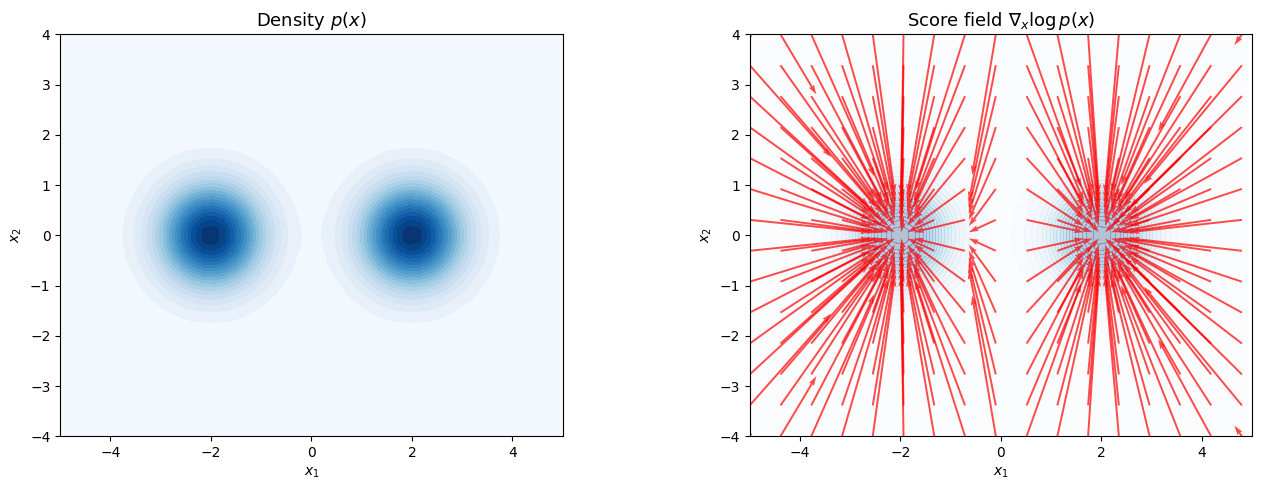

In [17]:
# Visualize score fields on a 2D Gaussian mixture
from scipy.stats import multivariate_normal

# Define a 2D mixture of Gaussians
means = [np.array([-2, 0]), np.array([2, 0])]
covs = [np.eye(2) * 0.5, np.eye(2) * 0.5]
weights = [0.5, 0.5]

def mixture_log_prob(x):
    """Log probability of Gaussian mixture."""
    probs = sum(
        w * multivariate_normal.pdf(x, mean=m, cov=c)
        for w, m, c in zip(weights, means, covs)
    )
    return np.log(probs + 1e-10)

def mixture_score(x):
    """Score (gradient of log prob) of Gaussian mixture."""
    total_prob = sum(
        w * multivariate_normal.pdf(x, mean=m, cov=c)
        for w, m, c in zip(weights, means, covs)
    )
    score = np.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        component_prob = w * multivariate_normal.pdf(x, mean=m, cov=c)
        inv_cov = np.linalg.inv(c)
        score += (component_prob / (total_prob + 1e-10))[..., None] * (-(x - m) @ inv_cov)
    return score

# Create grid
xx, yy = np.meshgrid(np.linspace(-5, 5, 50), np.linspace(-4, 4, 40))
grid = np.stack([xx, yy], axis=-1)

# Compute density and scores
log_prob = mixture_log_prob(grid.reshape(-1, 2)).reshape(xx.shape)
scores = mixture_score(grid.reshape(-1, 2)).reshape(*xx.shape, 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Density plot
axes[0].contourf(xx, yy, np.exp(log_prob), levels=20, cmap="Blues")
axes[0].set_title("Density $p(x)$", fontsize=13)
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].set_aspect("equal")

# Score field (arrows pointing toward high density)
axes[1].contourf(xx, yy, np.exp(log_prob), levels=20, cmap="Blues", alpha=0.3)
step = 3  # subsample for clarity
axes[1].quiver(
    xx[::step, ::step], yy[::step, ::step],
    scores[::step, ::step, 0], scores[::step, ::step, 1],
    color="red", alpha=0.7, scale=25
)
axes[1].set_title(r"Score field $\nabla_x \log p(x)$", fontsize=13)
axes[1].set_xlabel("$x_1$")
axes[1].set_ylabel("$x_2$")
axes[1].set_aspect("equal")

plt.tight_layout()

The arrows point toward the modes of the distribution. A diffusion model learns these score arrows at every noise level, then follows them from pure noise back to data.

## Comparing All Four Families

Now that we have seen lightweight local demos and precomputed outputs for all four families, let's compare them directly. (The flow example remains a 2D density-estimation demo, so the image comparison focuses on GAN, VAE, and diffusion outputs.)

(<Figure size 1200x500 with 1 Axes>,
 <Axes: title={'center': 'Comparison: GAN vs VAE vs Diffusion (MNIST)'}>)

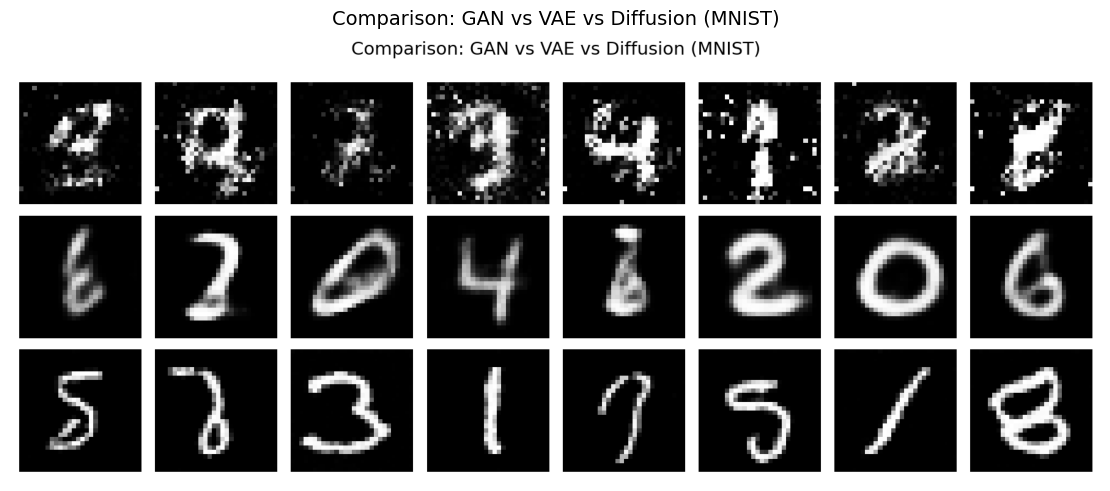

In [18]:
show_figure(
    "generative-models-comparison.png",
    figsize=(12, 5),
    title="Comparison: GAN vs VAE vs Diffusion (MNIST)",
)

| | GAN | VAE | Flow | Diffusion |
|---|---|---|---|---|
| **Training stability** | Unstable (adversarial) | Stable | Stable | Stable |
| **Sample quality** | Sharp but may have artifacts | Blurry | Moderate | Sharp and detailed |
| **Mode coverage** | May miss modes (collapse) | Good | Good | Excellent |
| **Likelihood** | Not available | Lower bound (ELBO) | Exact | Lower bound (ELBO); continuous-time formulations allow likelihood computation (costly) |
| **Inference speed** | Fast (1 pass) | Fast (1 pass) | Fast (1 pass) | Slow (T passes) |
| **Latent space** | No explicit encoder | Smooth, structured | Exact invertible mapping | No standard latent (but can use DDIM) |
| **Architecture constraint** | None | None | Must be invertible | None |
| **Training objective** | Minimax game | ELBO maximization | Max likelihood | Noise prediction (simplified ELBO) |

**When to use which:**

- **GANs**: When you need fast generation and can tolerate mode collapse. Good for real-time applications.
- **VAEs**: When you need a meaningful latent space for downstream tasks (interpolation, clustering, disentanglement). Good for representation learning.
- **Flows**: When you need exact likelihoods for density estimation, anomaly detection, or principled model comparison. Good for scientific applications where calibrated probabilities matter.
- **Diffusion models**: When sample quality and diversity matter most and you can afford slower generation. State of the art for image quality.

### Question 6

A researcher needs to generate synthetic chest X-rays to augment a training dataset for a pneumonia classifier.

1. Which generative model family (GAN, VAE, flow, or diffusion) would you recommend for this application? Consider both quality and practical constraints.
2. What are the risks of using synthetic medical images for training classifiers? Consider both statistical and ethical concerns.
3. How would you validate that the synthetic images are useful for the downstream classification task?

### Answer

1. **Diffusion models** are the best choice for medical image synthesis because: (a) they produce the highest-quality samples with fine anatomical details, (b) they have excellent mode coverage, ensuring diversity across patient demographics and disease presentations, (c) no mode collapse means all disease subtypes are represented. GANs might produce sharp images but could miss rare pathology types. VAEs would produce blurry images that lose diagnostic details. Flows would give exact likelihoods (useful for detecting out-of-distribution inputs) but historically produce lower-quality images than diffusion models.

2. **Statistical risks**: The generative model may not capture the full distribution of real pathology (missing rare conditions or unusual presentations). The classifier could learn artifacts of the generative model rather than true disease features. If the model memorizes training data, "synthetic" images could leak patient information. **Ethical risks**: Synthetic images that are indistinguishable from real ones raise concerns about data provenance and trust. Clinicians may not know which images in a dataset are real vs. synthetic.

3. **Validation approach**: (a) Train classifiers with varying proportions of real and synthetic data; measure accuracy on a held-out real test set. (b) Have radiologists perform a visual Turing test on a mix of real and synthetic images. (c) Compute distributional metrics (FID, precision/recall) between real and synthetic sets. (d) Check for memorization by comparing synthetic images to nearest neighbors in the training set.

## Modern Systems and State of the Art (2026)

### Latent Diffusion and Stable Diffusion

Running diffusion directly on high-resolution images (e.g., 512x512x3) is computationally expensive: the U-Net must process full-resolution tensors at every timestep. **Latent Diffusion Models** (Rombach et al., 2022) solve this by running the diffusion process in the latent space of a pretrained VAE.

The pipeline has three components:

1. **VAE encoder**: Compresses a 512x512 image to a 64x64x4 latent representation (48x fewer pixels)
2. **U-Net**: Performs diffusion (forward/reverse) in this compact latent space
3. **VAE decoder**: Converts the denoised latent back to a full-resolution image

This is where our two earlier models come together: the VAE provides compression, and the diffusion model provides high-quality generation.

**Text conditioning** is added via the CLIP text encoder (from the multi-modal models lecture). The text prompt is encoded into embeddings that are injected into the U-Net through cross-attention layers.

**Classifier-free guidance** trades diversity for prompt adherence. During training, the text condition is randomly dropped (replaced with null). At inference, both conditional and unconditional predictions are computed, and the conditional signal is amplified:

$$\hat{\epsilon} = \epsilon_\text{uncond} + w \cdot (\epsilon_\text{cond} - \epsilon_\text{uncond})$$

where $w > 1$ is the guidance scale. Typical values are $w = 5$-$15$.

### Architectural Evolution (2020-2026)

The field has evolved rapidly from the original DDPM:

**Diffusion Transformers (DiT).** Peebles & Xie (2023) replaced the U-Net backbone with a Transformer, treating image patches as tokens (just like ViT from the multi-modal models lecture). DiT scales better with compute and handles variable resolutions more naturally. Stable Diffusion 3.5 uses **MMDiT** (Multimodal Diffusion Transformer), which processes text and image tokens jointly with cross-attention.

**Rectified Flow / Flow Matching.** Instead of the complex curved denoising paths of DDPM, rectified flow uses **straight-line interpolation** between noise and data via optimal transport. The model learns a velocity field $v_\theta(x_t, t)$ instead of predicting noise:

$$x_t = (1 - t) \cdot x_0 + t \cdot \epsilon$$

This straight-line path requires far fewer steps to traverse. Flux and Stable Diffusion 3 use this approach, reducing sampling from 1000 steps to ~10 steps while maintaining quality.

**Consistency Models / Latent Consistency Models (LCM).** These distill the multi-step diffusion process into a model that can generate in 1-4 steps. The idea is to train a student model to directly predict the final output of the full denoising trajectory, collapsing many steps into one.

### Current State of the Art (2026)

| System | Architecture | Steps | Key Innovation |
|--------|-------------|-------|----------------|
| **DDPM** (2020) | U-Net | ~1000 | Noise prediction, simplified ELBO |
| **Stable Diffusion v1** (2022) | U-Net in latent space | ~50 | Latent diffusion + CLIP conditioning |
| **Stable Diffusion 3.5** (2024) | MMDiT-X (2.5B params) | ~28 | Joint text-image Transformer + rectified flow |
| **Flux 2** (2025) | Rectified flow Transformer | ~10 | Straight-line transport, fast inference |
| **Midjourney V8** (2026) | Proprietary | N/A | Native 2K resolution, 5x faster generation |
| **GPT Image** (2025) | Proprietary | N/A | Replaced DALL-E 3, integrated with GPT-4o |

The trend is clear: from U-Nets to Transformers, from noise prediction to velocity prediction, from 1000 steps to under 10.

### Process-Driven Image Generation

A recent direction challenges the single-pass generation paradigm entirely. Zhang et al. (2026) at Meta introduced **process-driven image generation**, where a unified multimodal model decomposes image synthesis into an interleaved reasoning trajectory of thoughts and actions, mimicking how a human painter works.

Instead of generating an image in one shot, the model iterates through four stages per cycle:

1. **Plan**: textual planning of the global layout
2. **Sketch**: visual drafting of a coarse image
3. **Inspect**: textual reflection that identifies elements that violate the prompt
4. **Refine**: visual refinement grounded in the evolving visual state

![Single-pass vs. process-driven generation](figs/meta-process-driven-overview.png)

*Comparison of single-pass generation (top) with the process-driven approach (bottom). The model plans, sketches, inspects for errors, and refines iteratively. When the inspect step detects conflicts with the prompt (highlighted in red), the refine step corrects them. Figure from Zhang et al. (2026).*

A single unified multimodal foundation model handles all four stages (both text reasoning and image generation) without relying on external models. The key technical contribution is dense, step-wise supervision that enforces spatial and semantic consistency of the visual intermediates at each step.

This approach achieves strong results on compositional benchmarks where single-pass models struggle, particularly for prompts with multiple objects, spatial relationships, or attribute bindings.

![Process-driven samples](figs/meta-process-driven-samples.png)

*Samples generated by the process-driven model, demonstrating high quality across diverse prompts. Figure from Zhang et al. (2026).*

### Video Generation

The same diffusion framework extends to video by treating video as a sequence of frames:

- **Sora 2** (OpenAI, 2025): Generates physically realistic video with synchronized audio
- **Runway Gen-4** (2025): Leading tool for cinematic quality
- **Veo 3** (Google, 2025): Sophisticated physics simulation and camera control

Video diffusion models typically use 3D U-Nets or spatiotemporal Transformers that process multiple frames jointly, maintaining temporal consistency.

### Question 7

Consider the architectural evolution of diffusion-based systems from DDPM (2020) to modern systems like Stable Diffusion 3 and Flux (2024-2025).

1. The evolution from U-Net to Transformer backbone mirrors the evolution in NLP (from RNNs to Transformers). Why do Transformers scale better for image generation?
2. Rectified flow / flow matching uses straight-line interpolation $x_t = (1-t) x_0 + t \epsilon$ instead of the curved DDPM noise schedule. Why does this allow fewer sampling steps?
3. Consistency models collapse the entire multi-step denoising trajectory into 1-4 steps. What is the fundamental tradeoff compared to full diffusion sampling?

### Answer

1. Transformers scale better because: (a) self-attention captures long-range dependencies (a U-Net's receptive field is limited by depth), (b) Transformers have a well-understood scaling law where more parameters and data consistently improve performance, (c) patch-based tokenization from ViT naturally handles variable resolutions, (d) joint attention over text and image tokens (as in MMDiT) is more natural than the cross-attention injection used in U-Net-based systems.

2. The DDPM forward process follows a curved path through noise space (controlled by the $\beta_t$ schedule), so the reverse process must take many small steps to follow this curve accurately. Rectified flow learns straight-line paths between noise and data via optimal transport. Straight lines can be traversed in fewer steps because each step covers more "distance" along the trajectory without accumulating discretization error.

3. Consistency models trade sample diversity and fine-grained control for speed. With fewer steps, the model has less opportunity to explore the probability landscape, so the generated distribution may be narrower (less diverse). The model also has fewer chances to incorporate conditioning signals, so prompt adherence or fine details may suffer. However, for many practical applications, 1-4 step generation with slightly lower quality is preferable to waiting for 50+ steps.

## Biomedical Applications

Generative models for images have found impactful applications in biomedicine:

**Medical image synthesis.** Generating synthetic training data for rare conditions where real data is scarce or privacy-sensitive. Diffusion models can generate realistic chest X-rays, retinal scans, or skin lesion images conditioned on diagnosis labels, enabling better classifier training.

**Image super-resolution and denoising.** Low-dose CT scans contain significant noise. Diffusion models can learn to denoise these images, producing diagnostic-quality scans from lower radiation doses. Similarly, microscopy images can be enhanced from low-resolution acquisitions.

**Drug discovery.** DiffDock (Corso et al., 2023) uses a diffusion process over the space of protein-ligand poses to predict how drug molecules bind to protein targets. Instead of diffusing over pixel space, it diffuses over 3D rotations and translations.

**Protein design.** RFdiffusion (Watson et al., 2023) generates novel protein structures by running diffusion in the space of protein backbone coordinates. Starting from random coordinates, the model iteratively refines them into physically plausible protein structures. This has enabled the design of proteins with novel functions not found in nature.

## Detecting AI-Generated Images

As generative models produce increasingly realistic images, detecting whether an image is real or AI-generated has become a critical challenge. This is an active arms race: as generators improve, detectors must evolve too.

### Frequency Domain Analysis

Generative models leave subtle traces in the **frequency spectrum** of images that are invisible to the human eye but detectable by algorithms.

Upsampling operations (used in GAN generators, VAE decoders, and U-Net decoders) introduce periodic patterns in the frequency domain. These spectral artifacts appear prominently near the **Nyquist frequencies** associated with the upsampling stride. The exact artifact locations depend on the specific upsampling method (transpose convolution, nearest-neighbor, bilinear), kernel size, and stride, but the pattern is consistent enough to serve as a detection signal.

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Frequency Spectrum: Real vs AI-Generated Images'}>)

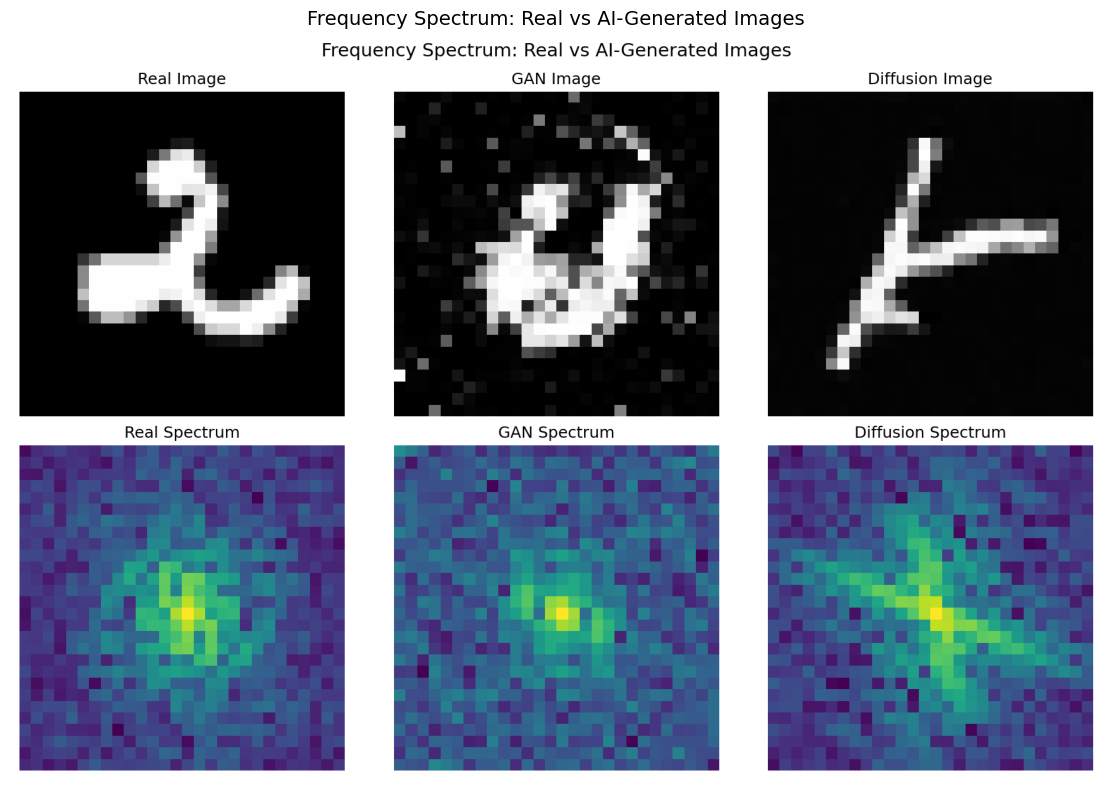

In [19]:
show_figure(
    "generative-models-spectrum-analysis.png",
    figsize=(12, 8),
    title="Frequency Spectrum: Real vs AI-Generated Images",
)

The frequency spectra may reveal differences: GAN images often show grid-like patterns from transpose convolution artifacts, while diffusion model images have spectra closer to real images (one reason they are harder to detect).

### Neural Network Detectors

The most common approach trains a **binary classifier** (typically a CNN or ViT) to distinguish real from generated images. These detectors can achieve over 95% accuracy on images from the same generator they were trained on.

Key challenges:

- **Generalization**: A detector trained on GAN images may fail on diffusion model images, and vice versa. Each generator leaves different artifacts.
- **Post-processing**: Simple operations like JPEG compression, resizing, or adding slight noise can degrade detection accuracy significantly.
- **New generators**: Detectors must be continuously updated as new models appear.

DIRE (Diffusion Reconstruction Error) is one notable approach: it passes the image through a pretrained diffusion model's forward-reverse process and measures the reconstruction error. Real images and diffusion-generated images reconstruct differently because of subtle distributional differences, allowing a classifier trained on these errors to detect generated content.

### Watermarking

Rather than detecting artifacts after the fact, **watermarking** embeds an invisible signal in generated images at creation time.

- **C2PA (Coalition for Content Provenance and Authenticity)**: An industry standard that attaches cryptographic metadata to images at creation, recording the provenance chain (what camera or AI model created it, whether it was edited). Adopted by Adobe, Google, Microsoft, and others.

- **SynthID (Google)**: Embeds an invisible watermark in the frequency domain of images generated by Google's models. The watermark is designed to survive common transformations (resizing, cropping, JPEG compression), though detection confidence varies by transformation type. However, targeted attacks that modify the spectral frequencies can degrade the watermark.

### The Detection Arms Race

Detection is fundamentally an **asymmetric problem**: the generator only needs to produce convincing images, while the detector must catch every possible generator. As models improve (fewer spectral artifacts, better training), detection becomes harder. Current research suggests that:

- Passive detection (analyzing artifacts) is becoming less reliable as generators improve
- Active approaches (watermarking, provenance tracking) are more sustainable long-term
- No single method is foolproof; robust detection requires combining multiple approaches
- In controlled studies of deepfake faces, automated detectors can reach ~97% accuracy while humans average ~60%, though these numbers vary by generator and image type

### Question 8

Consider the problem of detecting whether a medical image (e.g., a chest X-ray) was generated by an AI model or captured from a real patient.

1. Why is detection especially important in the medical domain compared to consumer photos?
2. A hospital trains a CNN detector on images from one specific GAN. A new diffusion-based generator is released that the detector has never seen. Will the detector work? Why or why not?
3. Would watermarking or frequency analysis be a better approach for medical image authentication? Consider the workflow of medical imaging.

### Answer

1. In medicine, a fake image could lead to incorrect diagnoses, inappropriate treatments, or fraudulent clinical trial results. Unlike consumer photos where the worst case is misinformation, medical deepfakes can directly harm patients. Additionally, medical images are part of legal health records, so provenance and authenticity are regulatory requirements.

2. Likely not. CNN detectors learn generator-specific artifacts (e.g., GAN checkerboard patterns from transpose convolutions). Diffusion models produce different artifacts (or fewer artifacts altogether). This is the cross-generator generalization problem. The detector would need retraining on diffusion model outputs, or a more general approach like DIRE (which leverages diffusion reconstruction error) could be used.

3. **Watermarking / provenance (C2PA)** is better for medical imaging. Medical images follow a controlled workflow: they are captured by specific devices (CT scanners, X-ray machines) and stored in PACS systems. C2PA-style provenance can be attached at capture time, so any image without valid provenance is flagged. Frequency analysis is fragile because medical images undergo routine processing (windowing, contrast adjustment, format conversion) that can destroy spectral artifacts. The controlled, institutional nature of medical imaging makes provenance tracking practical in a way it is not for consumer photos shared on social media.

## Summary

We covered four families of generative models, each with distinct strengths:

| | GAN | VAE | Flow | Diffusion |
|---|---|---|---|---|
| **Key idea** | Generator vs discriminator | Encode-decode with ELBO | Invertible transforms | Add noise, learn to reverse |
| **Objective** | Minimax adversarial loss | ELBO (recon + KL) | Max likelihood (exact) | Noise prediction (simplified ELBO) |
| **Quality** | Sharp, may have artifacts | Blurry | Moderate | Sharp, high fidelity |
| **Speed** | Fast (1 pass) | Fast (1 pass) | Fast (1 pass) | Slow (many passes) |
| **Year** | 2014 | 2014 | 2015 (NICE), 2017 (RealNVP) | 2020 (DDPM) |
| **Modern descendants** | StyleGAN3 | VQ-VAE-2, DALL-E 1 | Glow | Stable Diffusion, Flux, Midjourney |

**Connections to prior lectures:**

| This Lecture | Prior Lecture |
|---|---|
| Forward process is a Markov chain | MCMC: Markov chains and stationary distributions |
| DDPM training optimizes the ELBO | Variational inference: ELBO derivation |
| VAE reparameterization trick | Variational inference: reparameterization |
| U-Net trained with backpropagation | Deep learning: neural networks, PyTorch, CNNs |
| Timestep embedding uses sinusoidal encoding | Large language models: Transformer positional encoding |
| Text conditioning uses CLIP | Multi-modal models: CLIP |
| Latent diffusion uses a pretrained VAE | Variational inference: VAEs |
| Flow change-of-variables formula | Numeric integration: change of variables |
| DiT treats image patches as tokens | Multi-modal models: Vision Transformers |

## Recommended Resources

**Foundational papers:**

- Goodfellow et al. (2014), "Generative Adversarial Networks"
- Kingma & Welling (2014), "Auto-Encoding Variational Bayes"
- Dinh, Sohl-Dickstein, & Bengio (2017), "Density Estimation Using Real-NVP"
- Kingma & Dhariwal (2018), "Glow: Generative Flow with Invertible 1x1 Convolutions"
- Ho, Jain, & Abbeel (2020), "Denoising Diffusion Probabilistic Models"
- Song et al. (2021), "Score-Based Generative Modeling through Stochastic Differential Equations"
- Rombach et al. (2022), "High-Resolution Image Synthesis with Latent Diffusion Models"
- Lipman et al. (2023), "Flow Matching for Generative Modeling"
- Esser et al. (2024), "Scaling Rectified Flow Transformers for High-Resolution Image Synthesis"
- Zhang et al. (2026), "Think in Strokes, Not Pixels: Process-Driven Image Generation via Interleaved Reasoning"

**Tutorials and blog posts:**

- Lilian Weng, "What are Diffusion Models?" (https://lilianweng.github.io/posts/2021-07-11-diffusion-models/)
- Jay Alammar, "The Illustrated Stable Diffusion" (https://jalammar.github.io/illustrated-stable-diffusion/)
- Hugging Face, "The Annotated Diffusion Model" (https://huggingface.co/blog/annotated-diffusion)
- Yang Song, "Generative Modeling by Estimating Gradients of the Data Distribution" (https://yang-song.net/blog/2021/score/)

**Biomedical applications:**

- Watson et al. (2023), "De novo design of protein structure and function with RFdiffusion"
- Corso et al. (2023), "DiffDock: Diffusion Steps, Twists, and Turns for Molecular Docking"

**Acknowledgments:**

The diffusion models section of this lecture draws on illustrations and exposition from Jay Alammar's "The Illustrated Stable Diffusion" (https://jalammar.github.io/illustrated-stable-diffusion/), licensed under CC BY-NC-SA 4.0.